# Quantum Sensor Placement — QAOA per il posizionamento ottimale di stazioni meteo

**Obiettivo.** Dato un insieme di posizioni candidate per stazioni meteo e un insieme di zone
da monitorare, selezionare un sottoinsieme di *k* stazioni che massimizzi la copertura totale.
È un'istanza del **Maximum Coverage Problem** (NP-hard), qui risolta:

1. in modo esatto (forza bruta / eigensolver classico), come ground truth;
2. con un'euristica classica (greedy);
3. con **QAOA** (Quantum Approximate Optimization Algorithm) su simulatore statevector.

**Scope (weekend project).** Dati sintetici o CSV ARPA/Regione Lombardia già scaricato,
formulazione QUBO compatta (senza variabili ausiliarie), confronto quantistico vs classico
su istanze piccole (10-15 stazioni). Estensioni volutamente **fuori scope** per la v1: pesatura
delle zone su eventi meteo storici reali, esecuzione su hardware quantistico reale, confronto
con simulated annealing / solver D-Wave, ottimizzazione multi-obiettivo (copertura + costo).
Vedi le conclusioni in fondo per i dettagli.


## 0. Setup

In [ ]:
import time
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from qiskit_optimization import QuadraticProgram
from qiskit_optimization.algorithms import MinimumEigenOptimizer
from qiskit_optimization.minimum_eigensolvers import QAOA
from qiskit_algorithms.minimum_eigensolvers import NumPyMinimumEigensolver
from qiskit_algorithms.optimizers import COBYLA
from qiskit.primitives import StatevectorSampler

np.random.seed(0)
plt.rcParams["figure.dpi"] = 110


## 1. Configurazione

Se `CSV_PATH` punta a un file reale (es. il CSV scaricato da
[dati.lombardia.it](https://www.dati.lombardia.it/Ambiente/Stazioni-Idro-Nivo-Meteorologiche/nf78-nj6b)
o dal [portale Open Data del Comune di Milano](https://dati.comune.milano.it/dataset/bd2cbb52-70ac-4f2c-b046-066919ff3661)),
il notebook lo carica e prova a individuare automaticamente le colonne di nome/latitudine/longitudine.
Se il file non esiste (default), genera stazioni sintetiche placeholder così l'intera pipeline
è eseguibile fin da subito.

Se l'auto-detect delle colonne fallisce, apri il CSV, controlla le intestazioni e valorizza
`COLUMN_MAP`, es. `{'lat': 'Latitudine', 'lon': 'Longitudine', 'name': 'NomeStazione'}`.


In [2]:
# --- dati in ingresso ---
CSV_PATH = None  # es. "stazioni_arpa_milano.csv" — None => usa dati sintetici
COLUMN_MAP = None  # override manuale, es. {'lat': 'Latitudine', 'lon': 'Longitudine', 'name': 'Denominazione'}

# --- area di interesse (bounding box approssimativo di Milano) ---
BBOX = (45.40, 45.53, 9.05, 9.28)  # (lat_min, lat_max, lon_min, lon_max)

# --- parametri del problema ---
N_STATIONS_SYNTHETIC = 12   # usato solo se CSV_PATH è None
N_ZONES_SIDE = 5            # griglia N_ZONES_SIDE x N_ZONES_SIDE di zone da coprire
COVERAGE_RADIUS_KM = 3.5    # raggio di copertura di ciascuna stazione
K_STATIONS = 4              # quante stazioni selezionare (budget)
LAMBDA_OVERLAP = 1.0        # peso della penalità di sovrapposizione nel QUBO (vedi Step 3)
QAOA_REPS_LIST = [1, 2, 3]  # profondità del circuito QAOA da confrontare
SEED = 42


## 2. Step 1 — Stazioni candidate

`load_stations` carica un CSV reale (con auto-detect delle colonne) oppure genera
placeholder sintetici uniformemente distribuiti nel bounding box, così la pipeline
gira end-to-end anche prima di avere il file scaricato da ARPA/Regione Lombardia.

In [3]:
def load_stations(csv_path, column_map, bbox, n_synthetic, seed):
    if csv_path is not None:
        import os
        if not os.path.exists(csv_path):
            raise FileNotFoundError(f"CSV_PATH indicato ma non trovato: {csv_path}")
        df = pd.read_csv(csv_path)
        cols_lower = {c.lower(): c for c in df.columns}

        def find_col(candidates, key):
            if column_map and key in column_map:
                return column_map[key]
            for cand in candidates:
                if cand in cols_lower:
                    return cols_lower[cand]
            return None

        lat_col = find_col(['lat', 'latitude', 'latitudine', 'y'], 'lat')
        lon_col = find_col(['lon', 'lng', 'long', 'longitude', 'longitudine', 'x'], 'lon')
        name_col = find_col(['nome', 'denominazione', 'nomestazione', 'name', 'stazione', 'station'], 'name')

        if lat_col is None or lon_col is None:
            raise ValueError(
                "Non riesco a individuare le colonne lat/lon in automatico.\n"
                f"Colonne disponibili nel CSV: {list(df.columns)}\n"
                "Specifica COLUMN_MAP = {'lat': '...', 'lon': '...', 'name': '...'} nella cella di configurazione."
            )

        stations = pd.DataFrame({
            'name': df[name_col] if name_col else [f'station_{i}' for i in range(len(df))],
            'lat': df[lat_col].astype(float),
            'lon': df[lon_col].astype(float),
        }).dropna(subset=['lat', 'lon']).reset_index(drop=True)
        print(f"Caricate {len(stations)} stazioni reali da {csv_path}")
        return stations

    print("CSV_PATH è None: genero stazioni sintetiche placeholder per testare la pipeline.")
    rng = np.random.default_rng(seed)
    lat_min, lat_max, lon_min, lon_max = bbox
    return pd.DataFrame({
        'name': [f'station_{i}' for i in range(n_synthetic)],
        'lat': rng.uniform(lat_min, lat_max, n_synthetic),
        'lon': rng.uniform(lon_min, lon_max, n_synthetic),
    })


stations = load_stations(CSV_PATH, COLUMN_MAP, BBOX, N_STATIONS_SYNTHETIC, SEED)
N_STATIONS = len(stations)
stations.head()


CSV_PATH è None: genero stazioni sintetiche placeholder per testare la pipeline.


,name,lat,lon
0,station_0,45.500614,9.198089
1,station_1,45.457054,9.239235
2,station_2,45.511618,9.151985
3,station_3,45.490658,9.102265
4,station_4,45.412243,9.177555


## 3. Step 1b — Zone da coprire

Per semplicità le zone sono i centri di una griglia regolare sul bounding box. In una v2 si
potrebbero sostituire con i NIL (Nuclei di Identità Locale) di Milano o con celle pesate per
popolazione/rischio.

In [4]:
def define_zones(bbox, n_side):
    lat_min, lat_max, lon_min, lon_max = bbox
    lat_edges = np.linspace(lat_min, lat_max, n_side + 1)
    lon_edges = np.linspace(lon_min, lon_max, n_side + 1)
    rows = []
    for i in range(n_side):
        for j in range(n_side):
            rows.append({
                'zone_id': f'z{i}_{j}',
                'lat': (lat_edges[i] + lat_edges[i + 1]) / 2,
                'lon': (lon_edges[j] + lon_edges[j + 1]) / 2,
            })
    return pd.DataFrame(rows)


zones = define_zones(BBOX, N_ZONES_SIDE)
N_ZONES = len(zones)
print(f"{N_STATIONS} stazioni candidate, {N_ZONES} zone da coprire, budget k={K_STATIONS}")


12 stazioni candidate, 25 zone da coprire, budget k=4


## 4. Step 2 — Matrice di copertura

In [5]:
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2) ** 2 + np.cos(p1) * np.cos(p2) * np.sin(dlambda / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))


def build_coverage_matrix(stations, zones, radius_km):
    dist = haversine_km(
        stations['lat'].values[:, None], stations['lon'].values[:, None],
        zones['lat'].values[None, :], zones['lon'].values[None, :],
    )
    return (dist <= radius_km).astype(int)


cov = build_coverage_matrix(stations, zones, COVERAGE_RADIUS_KM)
print("Matrice di copertura:", cov.shape, "(stazioni x zone)")
print(f"Copertura per zona — min/media/max: {cov.sum(axis=0).min()}/{cov.sum(axis=0).mean():.1f}/{cov.sum(axis=0).max()}")
print(f"Copertura per stazione — min/media/max: {cov.sum(axis=1).min()}/{cov.sum(axis=1).mean():.1f}/{cov.sum(axis=1).max()}")


Matrice di copertura: (12, 25) (stazioni x zone)
Copertura per zona — min/media/max: 0/1.6/4
Copertura per stazione — min/media/max: 1/3.3/4


## 5. Step 3 — Formulazione QUBO

Il Maximum Coverage "esatto" richiederebbe una variabile ausiliaria binaria $y_j$ per zona
(con vincoli di disuguaglianza $y_j \le \sum_i \text{cov}_{ij} x_i$). In qiskit-optimization
questo si traduce in variabili di slack aggiuntive per ogni vincolo di disuguaglianza — con
10-15 zone il numero di qubit richiesti esplode rapidamente, poco adatto a un progetto weekend
su simulatore.

Si usa quindi un **proxy QUBO compatto** (solo $n$ variabili, una per stazione, nessuna slack):

$$\max \; \sum_i c_i x_i \;-\; \lambda \sum_{i<i'} o_{i,i'}\, x_i x_{i'} \qquad \text{s.t.} \quad \sum_i x_i = k$$

dove $c_i$ = numero di zone coperte dalla stazione $i$, $o_{i,i'}$ = numero di zone coperte da
*entrambe* le stazioni $i$ e $i'$. Si premia la copertura individuale e si penalizza la
sovrapposizione tra stazioni scelte insieme — un surrogato quadratico classico per problemi di
copertura submodulari. Più sotto confrontiamo il suo ottimo con quello vero (forza bruta sulla
copertura effettiva) per verificare quanto è un buon proxy su questa istanza.

In [6]:
def build_qubo(cov, k, lam):
    n = cov.shape[0]
    c = cov.sum(axis=1)
    overlap = cov @ cov.T

    qp = QuadraticProgram('max_coverage_proxy')
    for i in range(n):
        qp.binary_var(f'x{i}')

    linear = {f'x{i}': float(c[i]) for i in range(n)}
    quadratic = {
        (f'x{i}', f'x{j}'): -lam * float(overlap[i, j])
        for i in range(n) for j in range(i + 1, n) if overlap[i, j] > 0
    }
    qp.maximize(linear=linear, quadratic=quadratic)
    qp.linear_constraint(linear={f'x{i}': 1 for i in range(n)}, sense='==', rhs=k, name='budget')
    return qp


qp = build_qubo(cov, K_STATIONS, LAMBDA_OVERLAP)
print(qp.prettyprint())


Problem name: max_coverage_proxy

Maximize
  -x0*x11 - 2*x0*x2 - 2*x0*x6 - 4*x0*x7 - 2*x1*x10 - x1*x8 - 2*x2*x3 - 2*x2*x7
  - x3*x9 - x4*x8 - x4*x9 - 3*x6*x11 - 2*x6*x7 - x7*x11 + 4*x0 + 4*x1 + 2*x10
  + 3*x11 + 4*x2 + 4*x3 + 3*x4 + x5 + 4*x6 + 4*x7 + 3*x8 + 4*x9

Subject to
  Linear constraints (1)
    x0 + x1 + x10 + x11 + x2 + x3 + x4 + x5 + x6 + x7 + x8 + x9 == 4  'budget'

  Binary variables (12)
    x0 x1 x2 x3 x4 x5 x6 x7 x8 x9 x10 x11



## 6. Step 4 — Baseline classiche

`true_coverage` valuta l'obiettivo *reale* (zone uniche coperte), non il proxy: serve a
confrontare in modo equo tutti i metodi, quantistico incluso.

In [7]:
def true_coverage(selected_idx, cov):
    if len(selected_idx) == 0:
        return 0
    return int((cov[list(selected_idx)].sum(axis=0) > 0).sum())


def brute_force_optimal(cov, k):
    n = cov.shape[0]
    best_val, best_combo = -1, None
    for combo in itertools.combinations(range(n), k):
        val = true_coverage(combo, cov)
        if val > best_val:
            best_val, best_combo = val, combo
    return list(best_combo), best_val


def greedy_selection(cov, k):
    n = cov.shape[0]
    selected, remaining = [], set(range(n))
    for _ in range(k):
        gains = {i: true_coverage(selected + [i], cov) - true_coverage(selected, cov) for i in remaining}
        best_i = max(gains, key=gains.get)
        selected.append(best_i)
        remaining.remove(best_i)
    return selected, true_coverage(selected, cov)


sel_brute, cov_brute = brute_force_optimal(cov, K_STATIONS)
sel_greedy, cov_greedy = greedy_selection(cov, K_STATIONS)

res_exact_qubo = MinimumEigenOptimizer(NumPyMinimumEigensolver()).solve(qp)
sel_exact_qubo = [i for i in range(N_STATIONS) if round(res_exact_qubo.x[i]) == 1]
cov_exact_qubo = true_coverage(sel_exact_qubo, cov)

print(f"Forza bruta (obiettivo vero)   -> stazioni {sel_brute}  copertura {cov_brute}/{N_ZONES}")
print(f"Greedy (obiettivo vero)        -> stazioni {sel_greedy}  copertura {cov_greedy}/{N_ZONES}")
print(f"QUBO risolto esattamente(proxy)-> stazioni {sel_exact_qubo}  copertura reale {cov_exact_qubo}/{N_ZONES}  (gap dal vero ottimo: {cov_brute - cov_exact_qubo})")


Forza bruta (obiettivo vero)   -> stazioni [1, 2, 6, 9]  copertura 16/25
Greedy (obiettivo vero)        -> stazioni [0, 1, 3, 4]  copertura 15/25
QUBO risolto esattamente(proxy)-> stazioni [1, 2, 6, 9]  copertura reale 16/25  (gap dal vero ottimo: 0)


## 7. Step 5 — QAOA

Si risolve lo stesso QUBO con `MinimumEigenOptimizer` + `QAOA` (simulatore statevector,
ottimizzatore classico COBYLA), confrontando profondità diverse del circuito
(`QAOA_REPS_LIST`). Il `callback` registra il valore dell'obiettivo a ogni valutazione per il
grafico di convergenza dello Step 6.

In [8]:
def make_callback(history):
    def cb(evals, params, value, meta):
        val = value.real if hasattr(value, 'real') else value
        history.append((evals, val))
    return cb


qaoa_results = {}
qaoa_histories = {}

for reps in QAOA_REPS_LIST:
    history = []
    qaoa = QAOA(
        sampler=StatevectorSampler(),
        optimizer=COBYLA(maxiter=250),
        reps=reps,
        callback=make_callback(history),
    )
    t0 = time.time()
    res = MinimumEigenOptimizer(qaoa).solve(qp)
    elapsed = time.time() - t0

    sel = [i for i in range(N_STATIONS) if round(res.x[i]) == 1]
    qaoa_results[reps] = {
        'selected': sel,
        'proxy_obj': res.fval,
        'true_coverage': true_coverage(sel, cov),
        'time_s': elapsed,
    }
    qaoa_histories[reps] = history
    r = qaoa_results[reps]
    print(f"QAOA p={reps}: stazioni {r['selected']}  copertura reale {r['true_coverage']}/{N_ZONES}  "
          f"(proxy_obj={r['proxy_obj']:.1f}, {r['time_s']:.1f}s, {len(history)} valutazioni)")


QAOA p=1: stazioni [0, 1, 3, 4]  copertura reale 15/25  (proxy_obj=15.0, 1.8s, 30 valutazioni)


QAOA p=2: stazioni [1, 2, 6, 9]  copertura reale 16/25  (proxy_obj=16.0, 2.2s, 35 valutazioni)


QAOA p=3: stazioni [1, 2, 6, 9]  copertura reale 16/25  (proxy_obj=16.0, 3.5s, 50 valutazioni)


## 8. Step 6 — Visualizzazioni

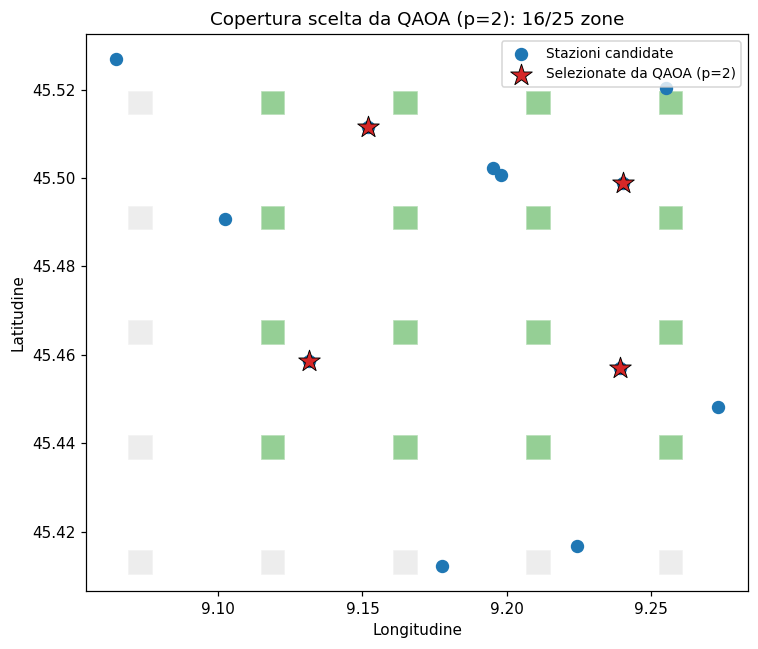

In [9]:
best_reps = max(qaoa_results, key=lambda r: qaoa_results[r]['true_coverage'])
sel_qaoa_best = qaoa_results[best_reps]['selected']
zone_covered_by_qaoa = cov[sel_qaoa_best].sum(axis=0) > 0 if sel_qaoa_best else np.zeros(N_ZONES, dtype=bool)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(zones['lon'], zones['lat'], s=260, marker='s',
           c=['#2ca02c' if c else '#dddddd' for c in zone_covered_by_qaoa],
           alpha=0.5, edgecolors='white', linewidths=1, label=None, zorder=1)
ax.scatter(stations['lon'], stations['lat'], s=60, c='#1f77b4', label='Stazioni candidate', zorder=2)
ax.scatter(stations['lon'].iloc[sel_qaoa_best], stations['lat'].iloc[sel_qaoa_best],
           s=220, c='#d62728', marker='*', edgecolors='black', linewidths=0.6,
           label=f'Selezionate da QAOA (p={best_reps})', zorder=3)
ax.set_xlabel('Longitudine'); ax.set_ylabel('Latitudine')
ax.set_title(f'Copertura scelta da QAOA (p={best_reps}): {qaoa_results[best_reps]["true_coverage"]}/{N_ZONES} zone')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout(); plt.show()


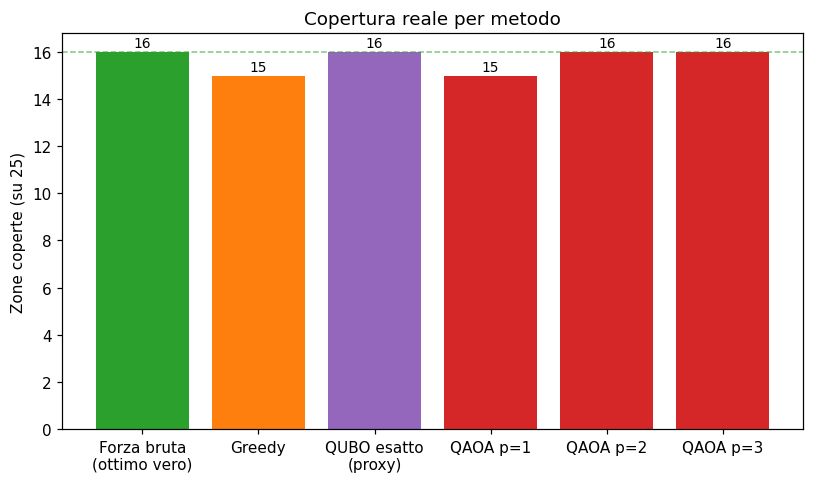

In [10]:
methods = ['Forza bruta\n(ottimo vero)', 'Greedy', 'QUBO esatto\n(proxy)'] + [f'QAOA p={r}' for r in QAOA_REPS_LIST]
values = [cov_brute, cov_greedy, cov_exact_qubo] + [qaoa_results[r]['true_coverage'] for r in QAOA_REPS_LIST]
colors = ['#2ca02c', '#ff7f0e', '#9467bd'] + ['#d62728'] * len(QAOA_REPS_LIST)

fig, ax = plt.subplots(figsize=(7.5, 4.5))
bars = ax.bar(methods, values, color=colors)
ax.axhline(cov_brute, color='#2ca02c', linestyle='--', linewidth=1, alpha=0.6)
ax.set_ylabel(f'Zone coperte (su {N_ZONES})')
ax.set_title('Copertura reale per metodo')
for b, v in zip(bars, values):
    ax.text(b.get_x() + b.get_width()/2, v + 0.2, str(v), ha='center', fontsize=9)
plt.tight_layout(); plt.show()


**Nota sul segno.** `MinimumEigenOptimizer` converte il problema di massimizzazione in un
Hamiltoniano da minimizzare (segno invertito, più un offset dovuto alla penalità del vincolo di
budget). Il `callback` di QAOA registra questa energia interna, non l'obiettivo proxy nelle
stesse unità di `res.fval` — per questo il grafico qui sotto mostra la traccia grezza
dell'ottimizzatore (valori più bassi = soluzione migliore per l'Hamiltoniano interno), utile per
vedere se/quanto COBYLA converge, senza cercare di farla coincidere numericamente con
`proxy_obj` stampato sopra.

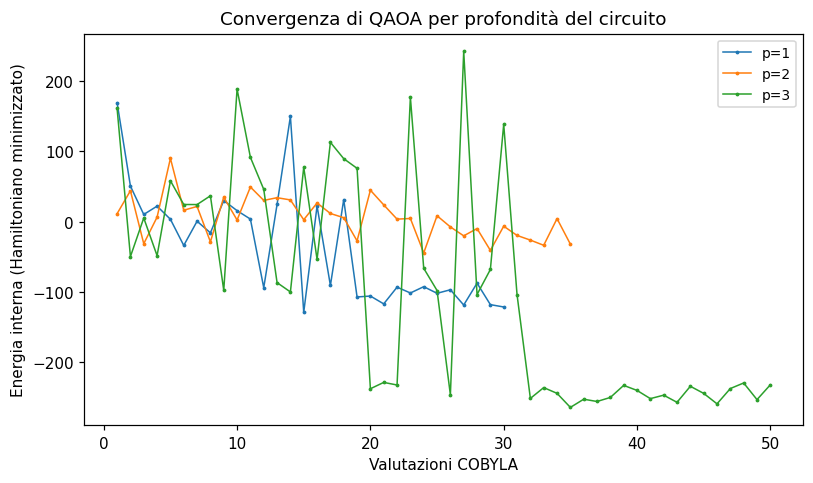

In [11]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
for reps, history in qaoa_histories.items():
    if history:
        evals, vals = zip(*history)
        ax.plot(evals, vals, marker='.', markersize=3, linewidth=1, label=f'p={reps}')
ax.set_xlabel('Valutazioni COBYLA'); ax.set_ylabel('Energia interna (Hamiltoniano minimizzato)')
ax.set_title('Convergenza di QAOA per profondità del circuito')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()


## 9. Riepilogo e prossimi passi

In [12]:
summary = pd.DataFrame(
    [
        {'metodo': 'Forza bruta (ottimo vero)', 'copertura': cov_brute},
        {'metodo': 'Greedy', 'copertura': cov_greedy},
        {'metodo': 'QUBO esatto (proxy)', 'copertura': cov_exact_qubo},
    ] + [
        {'metodo': f'QAOA p={r}', 'copertura': qaoa_results[r]['true_coverage']}
        for r in QAOA_REPS_LIST
    ]
)
summary['gap_da_ottimo'] = cov_brute - summary['copertura']
summary


,metodo,copertura,gap_da_ottimo
0,Forza bruta (ottimo vero),16,0
1,Greedy,15,1
2,QUBO esatto (proxy),16,0
3,QAOA p=1,15,1
4,QAOA p=2,16,0
5,QAOA p=3,16,0


**Cosa guardare nei risultati:**
- Quanto è vicino il proxy QUBO (risolto esattamente) alla vera soluzione ottima di forza bruta
  — misura la qualità della formulazione, indipendentemente dal quantum.
- Quanto è vicino QAOA all'ottimo del *proprio* QUBO al variare di `reps` (p) — misura la qualità
  dell'ottimizzazione quantistica stessa, che su simulatore statevector con poche variabili non
  ha vantaggi pratici ma è lo stesso identico flusso che si userebbe su hardware reale.
- Se QAOA non raggiunge l'ottimo: normale per un algoritmo approssimato con `p` basso e
  ottimizzatore classico (COBYLA) soggetto a minimi locali — è un risultato onesto, non un bug.

**Esplicitamente fuori scope per questa v1** (idee per un'estensione futura, tenute separate per
evitare scope creep):
- pesatura delle zone su eventi meteo estremi storici reali (dati ARPA);
- esecuzione su hardware quantistico reale (IBM Quantum) con analisi del rumore;
- confronto con simulated annealing / solver D-Wave sullo stesso QUBO;
- formulazione multi-obiettivo (copertura + costo di installazione/manutenzione).
